# imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import pickle
import os
import cortex
import neurosynth
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
import importlib.util
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# %config InlineBackend.figure_format = 'retina'

# set paths

In [3]:
annot_dir = '../../data/annotations_dfs/'
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings', 'k:1000')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings', 'k:1000')
pickle_dir = '../../data/pickles/'
braindata_dir = '../../data/brains/'
fig_dir = '../../figures/'
brainfig_dir = os.path.join(fig_dir,'brains/')

# load data

In [4]:
with open(pickle_dir+'fit_models.p', 'rb') as f:
    models_dict = pickle.load(f)
    
brainweights = np.load(braindata_dir+'HuthModelWeights.npy')
mask = np.load(braindata_dir+'mask.npy')

away_from_topics = np.load(braindata_dir+'away_from_topic_vector.npy')
toward_topics = np.load(braindata_dir+'toward_topic_vector.npy')

# load neural speech representation semantic model 

In [5]:
# credit: https://github.com/HuthLab/speechmodeltutorial
spec = importlib.util.spec_from_file_location('HuthSpeechModel', '../HuthSpeechModel/SemanticModel.py')
HSM = importlib.util.module_from_spec(spec)
spec.loader.exec_module(HSM)
corpus = HSM.SemanticModel.load('../HuthSpeechModel/data/english1000sm.hf5')

In [6]:
# percent of words in episode corpus covered in Huth semantic model
for episode in models_dict.keys():
    if episode != 'delayed':
        nwords_covered = len([i for i in list(models_dict[episode]['cv'].vocabulary_) if i in corpus.vocab])
        print('{0}: {1}% coverage'.format(episode, nwords_covered/len(list(models_dict[episode]['cv'].vocabulary_))))

atlep1: 0.7756132756132756% coverage
atlep2: 0.7621178225205071% coverage
arrdev: 0.7450372208436724% coverage


# create weighted brain map for each topic dimension

In [7]:
# for episode, mods in models_dict.items():
#     if episode != 'delayed':
#         # get distribution of word weights for each topic
#         topic_wordweights = mods['tm'].components_ / mods['tm'].components_.sum(axis=1)[:, np.newaxis]

#         # voxel responses for each word in the corpus
#         word_activations = []
#         # for each word in the episode
#         for word in mods['cv'].vocabulary_:

#             # if it's in the Huth model's vocab, use its weights
#             if word in corpus.vocab:
#                 wordweight = corpus[word]
#             # otherwise fill with nans
#             else:
#                 wordweight = np.full(985, np.nan)

#             # get voxel-wise response for word weight
#             voxweights = np.dot(wordweight, brainweights)
#             word_activations.append(voxweights)
        
#         # get voxel weights for each topic dimensions
#         word_act_vals = np.nan_to_num(np.array(word_activations)
#         topic_voxweights =  np.dot(topic_wordweights, word_act_vals)
        
#         # save out weighted brainmaps
#         np.save(braindata_dir+'{}/topic_voxelweights.npy'.format(episode), topic_voxweights)
        
        

In [7]:
episode_topic_voxweights = {ep : np.load(os.path.join(braindata_dir, ep, 'topic_voxelweights.npy'))
                            for ep in ['atlep1','atlep2','arrdev']}


# predicted activation differences immediate to delayed

In [8]:
percentile_show = 90

In [70]:
# most significant topics lost over delay
away_from_voxels = np.dot(away_from_topics, episode_topic_voxweights['atlep1'])

away_from_vol = cortex.Volume(away_from_voxels, 'S1', 'fullhead', mask=mask, cmap='coolwarm')

In [58]:
np.percentile(away_from_voxels, percentile_show)

4.5340220455526965e-05

Stopping server


In [74]:
away_from_vol.save_nii('/Users/paxtonfitzpatrick/Desktop/away_from_volume')

In [71]:
js_handle = cortex.webgl.show(away_from_vol, open_browser=True)

Started server on port 64774


In [73]:
js_handle.getImage('away_inflated_trilinear_left.png')

[{}]

In [33]:
js_handle._set_view(azimuth=[90], altitude=[90.5], mix=[0])

Unknown parameter azimuth!
Unknown parameter altitude!
Unknown parameter mix!


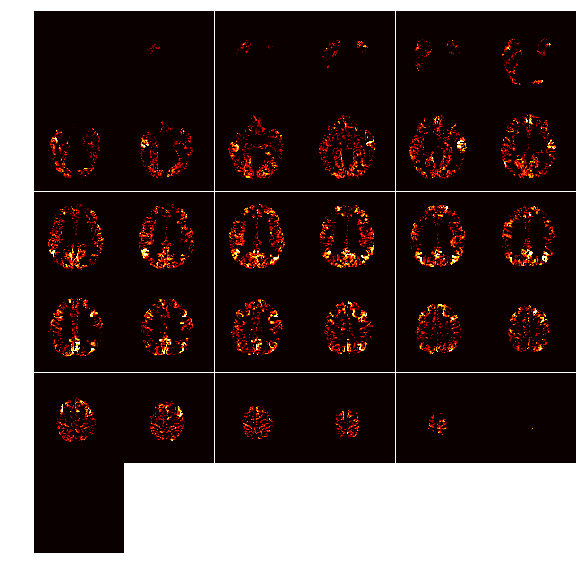

In [149]:
corrvolume = np.zeros(mask.shape)
corrvolume[mask>0] = voxweights

f = plt.figure(figsize=(10,10))
cortex.mosaic(corrvolume, vmin=0, vmax=.1, cmap='hot');

In [9]:
import neurosynth as ns

In [14]:
#from neurosynth.base.dataset import Dataset
dataset = neurosynth.base.dataset.Dataset(str('../neurosynth/data/database.txt'))

In [15]:
dataset.add_features(str('../neurosynth/data/features.txt'))

In [16]:
dataset.save(pickle_dir+'neurosynth_dataset.p')

In [18]:
dataset.activations

,id,doi,x,y,z,space,peak_id,table_id,table_num,title,authors,year,journal,i,j,k
0,9065511,NaN,38.000000,-48.000000,49.000000,MNI,548691,28698,1.,Environmental knowledge is subserved by separa...,"Aguirre GK, D'Esposito M",1997,The Journal of neuroscience : the official jou...,60,39,26
1,9065511,NaN,-4.000000,-70.000000,50.000000,MNI,548692,28698,1.,Environmental knowledge is subserved by separa...,"Aguirre GK, D'Esposito M",1997,The Journal of neuroscience : the official jou...,61,28,47
2,9065511,NaN,-34.000000,-52.000000,60.000000,MNI,548693,28698,1.,Environmental knowledge is subserved by separa...,"Aguirre GK, D'Esposito M",1997,The Journal of neuroscience : the official jou...,66,37,62
3,9065511,NaN,-23.000000,15.000000,67.000000,MNI,548694,28698,1.,Environmental knowledge is subserved by separa...,"Aguirre GK, D'Esposito M",1997,The Journal of neuroscience : the official jou...,70,70,56
4,9065511,NaN,-23.000000,-20.000000,68.000000,MNI,548695,28698,1.,Environmental knowledge is subserved by separa...,"Aguirre GK, D'Esposito M",1997,The Journal of neuroscience : the official jou...,70,53,56
5,9065511,NaN,42.000000,-47.000000,-19.000000,MNI,548696,28698,1.,Environmental knowledge is subserved by separa...,"Aguirre GK, D'Esposito M",1997,The Journal of neuroscience : the official jou...,26,40,24
6,9065511,NaN,25.000000,-35.000000,-8.000000,MNI,548697,28698,1.,Environmental knowledge is subserved by separa...,"Aguirre GK, D'Esposito M",1997,The Journal of neuroscience : the official jou...,32,46,32
7,9065511,NaN,-25.000000,-45.000000,-2.000000,MNI,548698,28698,1.,Environmental knowledge is subserved by separa...,"Aguirre GK, D'Esposito M",1997,The Journal of neuroscience : the official jou...,35,40,58
8,9065511,NaN,52.000000,-62.000000,14.000000,MNI,548699,28698,1.,Environmental knowledge is subserved by separa...,"Aguirre GK, D'Esposito M",1997,The Journal of neuroscience : the official jou...,43,32,19
9,9065511,NaN,21.000000,-81.000000,28.000000,MNI,548700,28698,1.,Environmental knowledge is subserved by separa...,"Aguirre GK, D'Esposito M",1997,The Journal of neuroscience : the official jou...,50,22,34
